**Author:** Tianqi Shen & GPT-4o

**Date:** 27 May 2026

# Empirical Evidence for Muon as an Early Exploration Optimizer
## Mixed-spiked Matrix Sensing Case ($\Sigma$ is diagonal matrix)

To examine when Muon performs well, we consider the mixed-spiked matrix sensing (MS) problem proposed in our paper. 

Recall that we define three projection matrices: $P_\star\in\mathbb{R}^{n\times r}$ (signal), $P_\diamond\in\mathbb{R}^{n\times r}$ (spike), and $P_\circ\in\mathbb{R}^{n\times r}$ (bulk). Let
$$
    P_\star P_\star^\top := U \in \mathbb{R}^{n\times n},
    \qquad
    P_\diamond P_\diamond^\top := V \in \mathbb{R}^{n\times n},
    \qquad
    P_\circ P_\circ^\top := W \in \mathbb{R}^{n\times n},
$$
and assume orthonormal columns, i.e., $P_\star^\top P_\star = P_\diamond^\top P_\diamond = P_\circ^\top P_\circ = I_r$.
We consider the objective
$$
    \min_{X\in\mathbb{R}^{n\times r}}
    \frac{1}{2} \mathbb{E}
    \left[
        \left\langle
            A,
            XX^\top - P_\star
        \right\rangle^2
    \right].
$$
The sensing matrix $A$ is sampled as
$$
    A = G + \pi_\star P_\star + \pi_\diamond P_\diamond + \pi_\circ P_\circ,
$$
where $G\sim \mathrm{GOE}(n)$ is an isotropic Gaussian noise component, and $\pi:=[\pi_\star,\pi_\diamond,\pi_\circ]^\top\sim\mathcal{N}(0,\Sigma)$
with $\Sigma\succeq 0$ (here, diagonal) a covariance matrix.
We also define the following matrix (here, diagonal)
$$
    \hat{K} := \frac{2}{n} I_3 + \Sigma 
    \begin{bmatrix}
        r & 0 & 0 \\
        0 & r & 0 \\
        0 & 0 & r
    \end{bmatrix}
    :=
    \begin{bmatrix}
        \hat{K}_{11} & 0 & 0 \\
        0 & \hat{K}_{22} & 0 \\
        0 & 0 & \hat{K}_{33}
    \end{bmatrix}.
$$

In [1]:
%matplotlib inline
#import matplotlib_inline   # setup output image format, do not use 'svg' if need 'pdf' output
#matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import matplotlib
import argparse
import numpy as np
from typing import List, Tuple
from itertools import chain
from tqdm import tqdm

### Load Hyper-parameters

In [2]:
# Load hyper-parameters
class Args:
    K11 = 0.5  # need K11 > 0
    K22 = 0.5  # need K22 > 0
    K33 = 0.5  # need K33 > 0
    T = 2.0  # T must be > 0
    switch_time = 0.12  # switch time must satisfy 0 < switch_time < T
    alpha0 = 1.2  # need alpha0 > 0
    beta0 = 0.8  # need beta0 > 0
    gamma0 = 0.4  # need gamma0 > 0
    continuous_eta1 = 0.001  # delta_t for GD
    continuous_eta2 = 0.001  # delta_t for Muon -> GD
    continuous_eta3 = 0.001  # delta_t for Muon
    discrete_eta1 = 0.028  # step_size for GD
    discrete_eta2 = 0.028  # step_size for Muon -> GD
    discrete_eta3 = 0.028  # step_size for Muon
args = Args()

### Functional helpers for continuous simulation

- If the iterates are initialized on the invariant manifold
$$
    \mathcal{M}
    :=
    \left\{
        M = \alpha P_\star + \beta P_\diamond + \gamma P_\circ
        :\; \alpha,\beta,\gamma \in \mathbb{R}
    \right\},
$$
  then the objective reduces to
$$
    f(\alpha,\beta,\gamma) =
    \frac{r}{n}
    \left[(\alpha-1)^2 + \beta^2 + \gamma^2\right]
    +
    \frac{r^2}{2}
    \begin{bmatrix}
        (\alpha-1) \\ \beta \\ \gamma
    \end{bmatrix}^{\top}
    \Sigma
    \begin{bmatrix}
        (\alpha-1) \\ \beta \\ \gamma
    \end{bmatrix}.
$$
  Under continuous-time gradient descent (the gradient-flow limit of vanilla GD), the trajectory satisfies the following ODE (with its solution)
$$
    \begin{cases}
        \dot{\alpha} = 4\hat{K}_{11}\alpha(1-\alpha)
        \quad&\Rightarrow\quad
        \alpha(t) = 
        \frac{1}{
            1 + \left((1-\alpha_0) / \alpha_0\right)
            e^{-4 \hat{K}_{11} t}
        },
        \\
        \dot{\beta} = -4\hat{K}_{22}\beta^2
        \quad&\Rightarrow\quad
        \beta(t) = 
        \frac{\beta_0}{
            1 + 4 \hat{K}_{22} \beta_0 t
        },
        \\
        \dot{\gamma} = -4\hat{K}_{33}\gamma^2
        \quad&\Rightarrow\quad
        \gamma(t) = 
        \frac{\gamma_0}{
            1 + 4 \hat{K}_{33} \gamma_0 t
        }.
    \end{cases}
$$

In [3]:
def gd_continuous(t, K11, K22, K33, alpha0, beta0, gamma0):
    """
    ODE:
      d alpha / dt =  4 K11 alpha (1 - alpha)
      d beta  / dt = -4 K22 beta^2
      d gamma / dt = -4 K33 gamma^2

    Closed forms:
      alpha(t) = 1 / (1 + ((1-alpha0)/alpha0) * exp(-4 K11 t))
      beta(t)  = beta0 / (1 + 4 K22 beta0 t)
      gamma(t) = gamma0 / (1 + 4 K33 gamma0 t)
    """
    t = np.asarray(t, dtype=float)

    # alpha logistic
    c = (1.0 - alpha0) / alpha0
    alpha = 1.0 / (1.0 + c * np.exp(-4.0 * K11 * t))

    # beta, gamma rational decay
    beta = beta0 / (1.0 + 4.0 * K22 * beta0 * t)
    gamma = gamma0 / (1.0 + 4.0 * K33 * gamma0 * t)

    return alpha, beta, gamma

- If the iterates are initialized on the invariant manifold
$$
    \mathcal X
    :=
    \left\{
        X=
        \big[a U\;\; b V\;\; c W\big]
        :\; a,b,c \in \mathbb{R}
    \right\},
$$
  then the objective reduces to
$$
    f(a,b,c) =
    \frac{r}{n}
    \left[(a^2-1)^2 + b^4 + c^4\right]
    +
    \frac{r^2}{2}
    \begin{bmatrix}
        (a^2-1) \\ b^2 \\ c^2
    \end{bmatrix}^{\top}
    \Sigma
    \begin{bmatrix}
        (a^2-1) \\ b^2 \\ c^2
    \end{bmatrix}.
$$
  For the simplified Muon dynamics, the trajectory satisfies the differential inclusion below. Writing $\alpha=a^2\ge0$, $\beta=b^2\ge0$ and $\gamma=c^2\ge0$, one obtains the explicit solutions
$$
    \begin{cases}
        \dot{\alpha}\in -2\sqrt{\alpha}\,
        \mathtt{sign}[\hat{K}_{11}(\alpha-1)]
        \quad&\Rightarrow\quad
        \alpha(t) = 
        (\max \{\sqrt{\alpha_0} - t, 1\})^2,
        \\
        \dot{\beta}\in -2\sqrt{\beta}\,
        \mathtt{sign}(\hat{K}_{22}\beta)
        \quad&\Rightarrow\quad
        \beta(t) = 
        (\max \{\sqrt{\beta_0} - t, 0\})^2,
        \\
        \dot{\gamma}\in -2\sqrt{\gamma}\,
        \mathtt{sign}(\hat{K}_{33}\gamma)
        \quad&\Rightarrow\quad
        \gamma(t) = 
        (\max \{\sqrt{\gamma_0} - t, 0\})^2.
    \end{cases}
$$

In [4]:
def muon_continuous(t, alpha0, beta0, gamma0):
    """
    Differential Inclusion:
      a = sqrt(alpha), target 1:  da/dt = -sign(K11 (a^2 - 1))
      b = sqrt(beta),  target 0:  db/dt = -sign(K22 b^2)
      c = sqrt(gamma), target 0:  dc/dt = -sign(K33 c^2)
    With initial alpha0, beta0, gamma0 > 0 => a0, b0, c0 > 0.
    Then b,c decrease linearly until 0 and stick at 0; a moves linearly toward 1 and sticks at 1.
    Returns alpha=a^2, beta=b^2, gamma=c^2.
    """
    t = np.asarray(t, dtype=float)

    a0 = np.sqrt(max(alpha0, 0.0))
    b0 = np.sqrt(max(beta0, 0.0))
    c0 = np.sqrt(max(gamma0, 0.0))

    # a -> 1 at speed 1
    if a0 >= 1.0:
        a = np.maximum(1.0, a0 - t)
    else:
        a = np.minimum(1.0, a0 + t)

    # b,c -> 0 at speed 1 (for b0,c0>=0)
    b = np.maximum(0.0, b0 - t)
    c = np.maximum(0.0, c0 - t)

    return a * a, b * b, c * c

- Hybrid optimizers: Muon first, then switch to GD

In [5]:
def make_time_grid(T: float, dt: float):
    if dt <= 0:
        raise ValueError("eta (used as plotting dt) must be > 0.")
    n = int(np.floor(T / dt)) + 1
    t = np.arange(n, dtype=float) * dt
    # Ensure last point hits T for nicer x-limits/legend consistency
    if t[-1] < T:
        t = np.append(t, T)
    return t

def muon2gd_continuous(t, tswitch, K11, K22, K33, alpha0, beta0, gamma0):
    """
    For each time in t:
      if t < tswitch: use Muon continuous from (alpha0, beta0, gamma0) at that time
      else: use GD continuous starting at state at tswitch (from Muon), evolving for (t - tswitch).
    """
    t = np.asarray(t, dtype=float)

    # state at switch from Muon
    alpha_sw, beta_sw, gamma_sw = muon_continuous(np.array([tswitch]), alpha0, beta0, gamma0)
    alpha_sw, beta_sw, gamma_sw = float(alpha_sw[0]), float(beta_sw[0]), float(gamma_sw[0])

    alpha = np.zeros_like(t, dtype=float)
    beta = np.zeros_like(t, dtype=float)
    gamma = np.zeros_like(t, dtype=float)

    mask_pre = (t < tswitch)
    mask_post = ~mask_pre

    if np.any(mask_pre):
        alpha_pre, beta_pre, gamma_pre = muon_continuous(t[mask_pre], alpha0, beta0, gamma0)
        alpha[mask_pre], beta[mask_pre], gamma[mask_pre] = alpha_pre, beta_pre, gamma_pre

    if np.any(mask_post):
        tau = t[mask_post] - tswitch
        alpha_post, beta_post, gamma_post = gd_continuous(tau, K11, K22, K33, alpha_sw, beta_sw, gamma_sw)
        alpha[mask_post], beta[mask_post], gamma[mask_post] = alpha_post, beta_post, gamma_post

    return alpha, beta, gamma, tswitch

### Run Simulation (“continuous” setting)

In [6]:
print("-------- GD Trajectory --------")
t1 = make_time_grid(args.T, args.continuous_eta1)
alpha1, beta1, gamma1 = gd_continuous(t1, args.K11, args.K22, args.K33, args.alpha0, args.beta0, args.gamma0)
print("-------- Muon Trajectory --------")
t3 = make_time_grid(args.T, args.continuous_eta3)
alpha3, beta3, gamma3 = muon_continuous(t3, args.alpha0, args.beta0, args.gamma0)
print("-------- Muon->GD Trajectory --------")
t2 = make_time_grid(args.T, args.continuous_eta2)
alpha2, beta2, gamma2, t_sw_eff = muon2gd_continuous(t2, args.switch_time, args.K11, args.K22, args.K33, 
                                                     args.alpha0, args.beta0, args.gamma0)

-------- GD Trajectory --------
-------- Muon Trajectory --------
-------- Muon->GD Trajectory --------


### Plot Results (“continuous” setting)

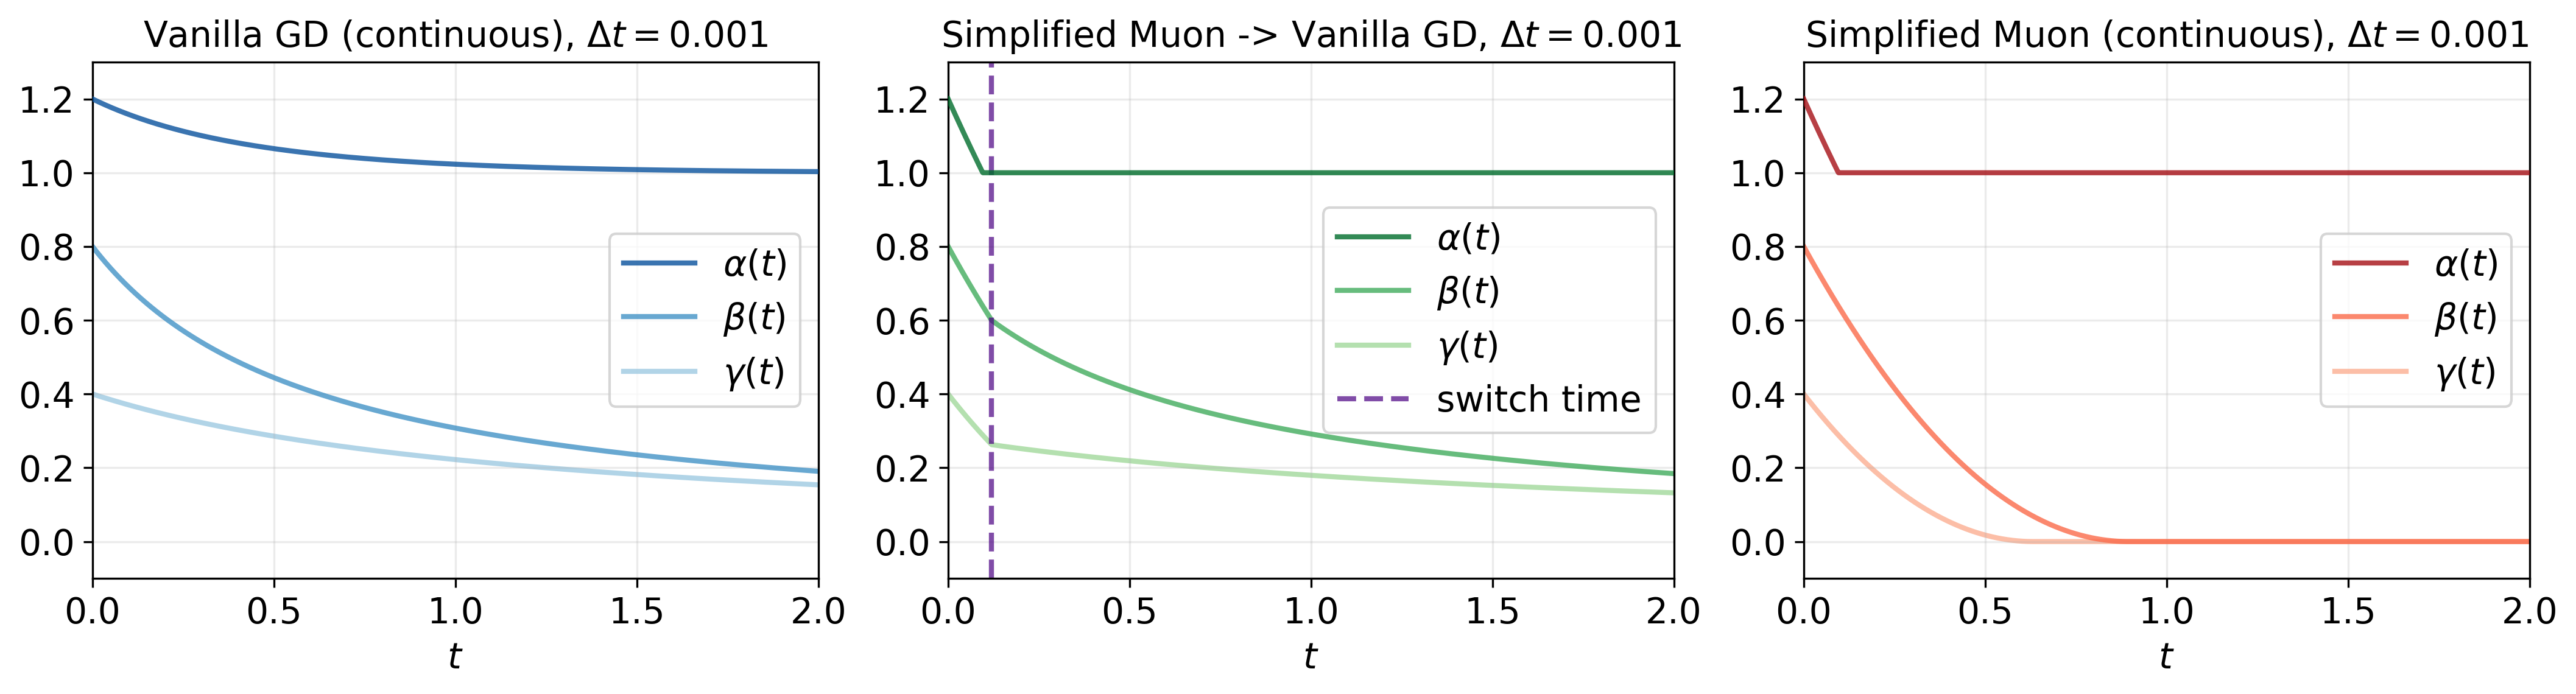

Saved figure to: mixed_spiked_ms_diag_continuous.pdf


In [7]:
blues  = ("#08519c", "#4292c6", "#9ecae1")
greens = ("#006d2c", "#41ab5d", "#a1d99b")
reds   = ("#a50f15", "#fb6a4a", "#fcae91")

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(14.2, 3.9), gridspec_kw=dict(width_ratios=[1.0, 1.0, 1.0]))

ax0.plot(t1, alpha1, color=blues[0], lw=2.0, label=r"$\alpha(t)$", drawstyle="default", zorder=3, alpha=0.8)
ax0.plot(t1, beta1, color=blues[1], lw=2.0, label=r"$\beta(t)$",  drawstyle="default", zorder=2, alpha=0.8)
ax0.plot(t1, gamma1, color=blues[2], lw=2.0, label=r"$\gamma(t)$", drawstyle="default", zorder=1, alpha=0.8)
ax0.set_xlabel(r"$t$", fontsize=14)
ax0.grid(True, alpha=0.25)
ax0.set_ylim(-0.1, 1.3)
ax0.set_xlim(float(np.min(t1)), float(np.max(t1)))
ax0.legend(loc="center right", frameon=True, fontsize=14)
ax0.tick_params(axis='both', labelsize=14)
ax0.set_title(rf"Vanilla GD (continuous), $\Delta t={args.continuous_eta1:g}$", fontsize=14)

ax1.plot(t2, alpha2, color=greens[0], lw=2.0, label=r"$\alpha(t)$", drawstyle="default", zorder=3, alpha=0.8)
ax1.plot(t2, beta2, color=greens[1], lw=2.0, label=r"$\beta(t)$",  drawstyle="default", zorder=2, alpha=0.8)
ax1.plot(t2, gamma2, color=greens[2], lw=2.0, label=r"$\gamma(t)$", drawstyle="default", zorder=1, alpha=0.8)
ax1.axvline(args.switch_time, label="switch time",
            color='#4B0082', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel(r"$t$", fontsize=14)
ax1.grid(True, alpha=0.25)
ax1.set_ylim(-0.1, 1.3)
ax1.set_xlim(float(np.min(t2)), float(np.max(t2)))
ax1.legend(loc="center right", frameon=True, fontsize=14)
ax1.tick_params(axis='both', labelsize=14)
ax1.set_title(rf"Simplified Muon -> Vanilla GD, $\Delta t={args.continuous_eta2:g}$", fontsize=14)

ax2.plot(t3, alpha3, color=reds[0], lw=2.0, label=r"$\alpha(t)$", drawstyle="default", zorder=3, alpha=0.8)
ax2.plot(t3, beta3, color=reds[1], lw=2.0, label=r"$\beta(t)$",  drawstyle="default", zorder=2, alpha=0.8)
ax2.plot(t3, gamma3, color=reds[2], lw=2.0, label=r"$\gamma(t)$", drawstyle="default", zorder=1, alpha=0.8)
ax2.set_xlabel(r"$t$", fontsize=14)
ax2.grid(True, alpha=0.25)
ax2.set_ylim(-0.1, 1.3)
ax2.set_xlim(float(np.min(t3)), float(np.max(t3)))
ax2.legend(loc="center right", frameon=True, fontsize=14)
ax2.tick_params(axis='both', labelsize=14)
ax2.set_title(rf"Simplified Muon (continuous), $\Delta t={args.continuous_eta3:g}$", fontsize=14)

fig.tight_layout()
plt.show()
fig.savefig("mixed_spiked_ms_diag_continuous.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: mixed_spiked_ms_diag_continuous.pdf")

### Functional helpers for discrete simulation

In [8]:
def gd_step(alpha, beta, gamma, K11, K22, K33, eta):
    """
    Euler discretization of:
      d alpha / dt =  4 K11 alpha (1 - alpha)
      d beta  / dt = -4 K22 beta^2
      d gamma / dt = -4 K33 gamma^2
    """
    dalpha = 4.0 * K11 * alpha * (1.0 - alpha)
    dbeta = -4.0 * K22 * (beta ** 2)
    dgamma = -4.0 * K33 * (gamma ** 2)

    alpha_next = alpha + eta * dalpha
    beta_next  = beta  + eta * dbeta
    gamma_next = gamma + eta * dgamma

    # numerical safety: keep nonnegative for beta/gamma (ODE preserves it)
    beta_next = max(beta_next, 0.0)
    gamma_next = max(gamma_next, 0.0)

    return alpha_next, beta_next, gamma_next

def gd_discrete(T, eta, K11, K22, K33, alpha0, beta0, gamma0):
    if eta <= 0:
        raise ValueError("eta must be > 0.")
    n = int(np.floor(T / eta)) + 1
    t = np.arange(n, dtype=float) * eta
    
    alpha_traj = np.zeros(n, dtype=float)
    beta_traj = np.zeros(n, dtype=float)
    gamma_traj = np.zeros(n, dtype=float)

    alpha, beta, gamma = float(alpha0), float(beta0), float(gamma0)
    for k in range(n):
        alpha_traj[k], beta_traj[k], gamma_traj[k] = alpha, beta, gamma
        alpha, beta, gamma = gd_step(alpha, beta, gamma, K11, K22, K33, eta)

    return t, alpha_traj, beta_traj, gamma_traj

In [9]:
def sign_with_zero(x: float) -> float:
    if x > 0:
        return 1.0
    if x < 0:
        return -1.0
    return 0.0

def muon_step(alpha, beta, gamma, eta):
    """
    Use sqrt variables:
      a = sqrt(alpha), target 1: a <- a - eta * sign(K11 (a^2 - 1))
      b = sqrt(beta),  target 0: b <- b - eta * sign(K22 b^2)
      c = sqrt(gamma), target 0: c <- c - eta * sign(K33 c^2)
    Then square back.
    This creates overshoot + sign flip oscillations for finite eta.
    """
    a = np.sqrt(max(alpha, 0.0))
    b = np.sqrt(max(beta,  0.0))
    c = np.sqrt(max(gamma, 0.0))

    a = a - eta * sign_with_zero(a ** 2 - 1.0)
    b = b - eta * sign_with_zero(b ** 2 - 0.0)
    c = c - eta * sign_with_zero(c ** 2 - 0.0)

    return a * a, b * b, c * c

def muon_discrete(T, eta, alpha0, beta0, gamma0):
    if eta <= 0:
        raise ValueError("eta must be > 0.")
    n = int(np.floor(T / eta)) + 1
    t = np.arange(n, dtype=float) * eta

    alpha_traj = np.zeros(n, dtype=float)
    beta_traj = np.zeros(n, dtype=float)
    gamma_traj = np.zeros(n, dtype=float)

    alpha, beta, gamma = float(alpha0), float(beta0), float(gamma0)
    for k in range(n):
        alpha_traj[k], beta_traj[k], gamma_traj[k] = alpha, beta, gamma
        alpha, beta, gamma = muon_step(alpha, beta, gamma, eta)

    return t, alpha_traj, beta_traj, gamma_traj

In [10]:
def muon2gd_discrete(T, eta, tswitch, K11, K22, K33, alpha0, beta0, gamma0):
    """
    Hybrid on a single discrete grid with step eta:
      for t_k < tswitch : Muon step
      for t_k >= tswitch: GD step
    Switching occurs at the first k such that t_k >= tswitch.
    """
    if eta <= 0:
        raise ValueError("eta must be > 0.")
    n = int(np.floor(T / eta)) + 1
    t = np.arange(n, dtype=float) * eta
    k_switch = int(np.ceil(tswitch / eta))  # first index with t_k >= tswitch
    k_switch = np.clip(k_switch, 0, n - 1)

    alpha_traj = np.zeros(n, dtype=float)
    beta_traj = np.zeros(n, dtype=float)
    gamma_traj = np.zeros(n, dtype=float)

    alpha, beta, gamma = float(alpha0), float(beta0), float(gamma0)
    for k in range(n):
        alpha_traj[k], beta_traj[k], gamma_traj[k] = alpha, beta, gamma
        if k < k_switch:
            alpha, beta, gamma = muon_step(alpha, beta, gamma, eta)
        else:
            alpha, beta, gamma = gd_step(alpha, beta, gamma, K11, K22, K33, eta)

    return t, alpha_traj, beta_traj, gamma_traj, k_switch

### Run Simulation (“discrete” setting)

In [11]:
print("-------- GD Trajectory --------")
t1, alpha1, beta1, gamma1 = gd_discrete(args.T, args.discrete_eta1, args.K11, args.K22, args.K33, 
                                        args.alpha0, args.beta0, args.gamma0)
print("-------- Muon Trajectory --------")
t3, alpha3, beta3, gamma3 = muon_discrete(args.T, args.discrete_eta3, args.alpha0, args.beta0, args.gamma0)
print("-------- Muon->GD Trajectory --------")
t2, alpha2, beta2, gamma2, k_sw_eff = muon2gd_discrete(args.T, args.discrete_eta2, args.switch_time, 
                                                       args.K11, args.K22, args.K33,
                                                       args.alpha0, args.beta0, args.gamma0)

-------- GD Trajectory --------
-------- Muon Trajectory --------
-------- Muon->GD Trajectory --------


### Plot Results (“discrete” setting)

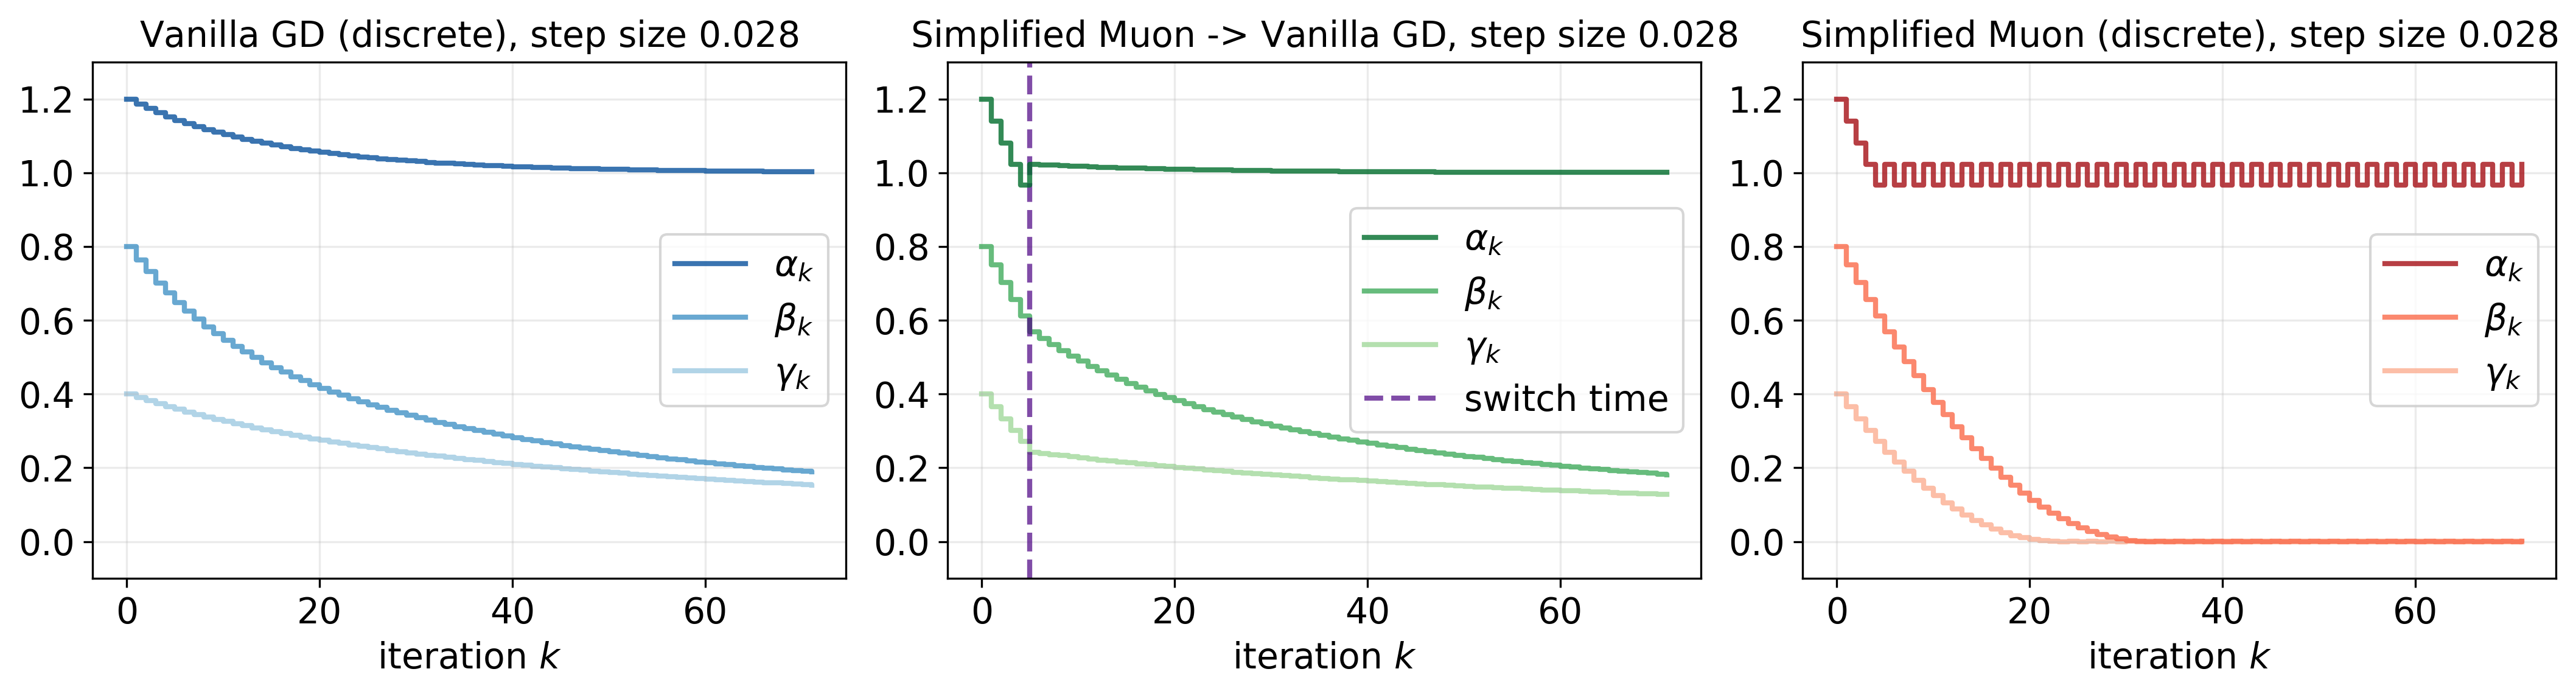

Saved figure to: mixed_spiked_ms_diag_discrete.pdf


In [12]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(14.2, 3.9), gridspec_kw=dict(width_ratios=[1.0, 1.0, 1.0]))

ax0.plot(range(len(t1)), alpha1, color=blues[0], lw=2.0, label=r"$\alpha_k$", drawstyle="steps-post", zorder=3, alpha=0.8)
ax0.plot(range(len(t1)), beta1, color=blues[1], lw=2.0, label=r"$\beta_k$",  drawstyle="steps-post", zorder=2, alpha=0.8)
ax0.plot(range(len(t1)), gamma1, color=blues[2], lw=2.0, label=r"$\gamma_k$", drawstyle="steps-post", zorder=1, alpha=0.8)
ax0.set_xlabel(r"iteration $k$", fontsize=14)
ax0.grid(True, alpha=0.25)
ax0.set_ylim(-0.1, 1.3)
ax0.legend(loc="center right", frameon=True, fontsize=14)
ax0.tick_params(axis='both', labelsize=14)
ax0.set_title(rf"Vanilla GD (discrete), step size ${args.discrete_eta1:g}$", fontsize=14)

ax1.plot(range(len(t2)), alpha2, color=greens[0], lw=2.0, label=r"$\alpha_k$", drawstyle="steps-post", zorder=3, alpha=0.8)
ax1.plot(range(len(t2)), beta2, color=greens[1], lw=2.0, label=r"$\beta_k$",  drawstyle="steps-post", zorder=2, alpha=0.8)
ax1.plot(range(len(t2)), gamma2, color=greens[2], lw=2.0, label=r"$\gamma_k$", drawstyle="steps-post", zorder=1, alpha=0.8)
ax1.axvline(k_sw_eff, label="switch time", color='#4B0082', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel(r"iteration $k$", fontsize=14)
ax1.grid(True, alpha=0.25)
ax1.set_ylim(-0.1, 1.3)
ax1.legend(loc="center right", frameon=True, fontsize=14)
ax1.tick_params(axis='both', labelsize=14)
ax1.set_title(rf"Simplified Muon -> Vanilla GD, step size ${args.discrete_eta2:g}$", fontsize=14)

ax2.plot(range(len(t3)), alpha3, color=reds[0], lw=2.0, label=r"$\alpha_k$", drawstyle="steps-post", zorder=3, alpha=0.8)
ax2.plot(range(len(t3)), beta3, color=reds[1], lw=2.0, label=r"$\beta_k$",  drawstyle="steps-post", zorder=2, alpha=0.8)
ax2.plot(range(len(t3)), gamma3, color=reds[2], lw=2.0, label=r"$\gamma_k$", drawstyle="steps-post", zorder=1, alpha=0.8)
ax2.set_xlabel(r"iteration $k$", fontsize=14)
ax2.grid(True, alpha=0.25)
ax2.set_ylim(-0.1, 1.3)
ax2.legend(loc="center right", frameon=True, fontsize=14)
ax2.tick_params(axis='both', labelsize=14)
ax2.set_title(rf"Simplified Muon (discrete), step size ${args.discrete_eta3:g}$", fontsize=14)

fig.tight_layout()
plt.show()
fig.savefig("mixed_spiked_ms_diag_discrete.pdf", dpi=300, format="pdf", bbox_inches="tight")
print(f"Saved figure to: mixed_spiked_ms_diag_discrete.pdf")